# Task 12 — Model Interpretation with SHAP and LIME

## Objective

The objective of this task is to interpret a credit-risk classification model using SHAP and LIME. The analysis focuses on understanding which features influence model predictions at both global and individual levels, while also providing a fairness-audit framework for responsible credit decisions.

## Dataset

**Dataset:** German Credit Dataset (Original UCI Statlog German Credit Data)

**Source:** UCI Machine Learning Repository

**Dataset Size:** 1,000 records and 21 columns  
**Input Features:** 20  
**Target:** Credit Risk

The dataset contains information about applicants' credit history, financial status, employment, loan details, housing, age, and other personal/financial attributes. The target variable represents whether an applicant has good or bad credit risk.

## Business Context

A bank uses an automated credit-scoring model to support loan decisions. Since customers may require an understandable reason for an automated decision, this task focuses on explaining model predictions using SHAP and LIME.

The explanations will help identify the features contributing to credit-risk predictions and support transparent and responsible model interpretation.

## Step 2 — Import Required Libraries

The required libraries are imported for data analysis, preprocessing, model development, evaluation, visualization, and model interpretation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


### Observation

All required libraries for data preprocessing, model development, evaluation, and visualization have been imported successfully.

### Step 3 — Load the German Credit Dataset

The German Credit dataset is used in this task to develop a credit-risk classification model and interpret its predictions using SHAP and LIME. The dataset contains customer credit information and a target class representing credit risk.


In [3]:
from google.colab import files
import pandas as pd

# Upload the German Credit dataset
uploaded = files.upload()

Saving GermanData_Credit.csv to GermanData_Credit.csv


In [4]:
import pandas as pd

# Load the uploaded dataset
file_path = "/content/GermanData_Credit.csv"

df = pd.read_csv(file_path, header=None)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (1000, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### Step 4 — Define Dataset Features

The German Credit dataset contains 1,000 credit records and 20 input features with one target variable. Since the raw dataset does not contain column names, meaningful feature names are assigned based on the German Credit dataset specification. The final column represents the credit-risk class.


In [5]:
# Define meaningful column names for the German Credit dataset

columns = [
    "checking_status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_status",
    "employment",
    "installment_rate",
    "personal_status",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker",
    "credit_risk"
]

df.columns = columns

print("Column names assigned successfully.")
print("Number of columns:", len(df.columns))

df.head()

Column names assigned successfully.
Number of columns: 21


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
# Display dataset information

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (1000, 21)

Column names:
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_rate', 'personal_status', 'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'credit_risk']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_status          1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_status           1000 non-null   object
 6   employment               1000 non-null   object
 7   installment_rate    

### Step 5 — Target Variable Analysis

The target variable `credit_risk` represents the credit risk class of each customer. The raw dataset uses two classes: `1` for good credit risk and `2` for bad credit risk. The target distribution is examined before preprocessing to understand the class balance and identify whether the dataset is imbalanced.


In [7]:
# Analyze the target variable

print("Credit Risk Distribution:")
print(df["credit_risk"].value_counts().sort_index())

print("\nCredit Risk Percentage:")
print(
    df["credit_risk"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Credit Risk Distribution:
credit_risk
1    700
2    300
Name: count, dtype: int64

Credit Risk Percentage:
credit_risk
1    70.0
2    30.0
Name: proportion, dtype: float64


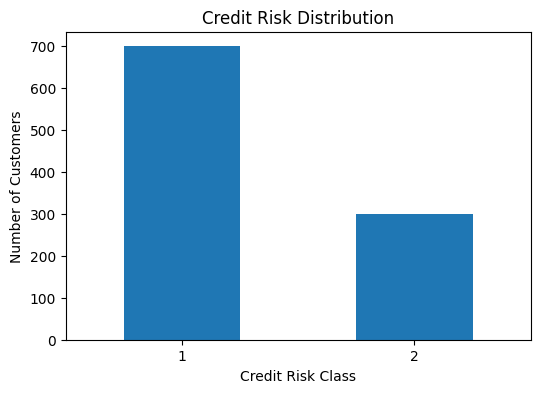

In [8]:
# Visualize the target distribution

import matplotlib.pyplot as plt

df["credit_risk"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk Class")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Step 6 — Data Quality Check

Before preprocessing, the dataset is checked for missing values and duplicate records. Identifying these issues early helps prevent unreliable model training and ensures that the interpretation results are based on clean and consistent data.


In [9]:
# Check for missing values and duplicate records

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
checking_status            0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_status             0
employment                 0
installment_rate           0
personal_status            0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
dependents                 0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

Total missing values: 0

Number of duplicate rows: 0


In [10]:
# Display basic descriptive statistics

print("Numerical Feature Summary:")
df.describe()

Numerical Feature Summary:


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


### Step 7 — Separate Features and Target

The dataset is divided into input features and the target variable. The 20 customer-related attributes are used as predictors, while `credit_risk` is treated as the target variable. Separating the target before preprocessing helps avoid data leakage and keeps the modeling workflow organized.


In [11]:
# Separate input features and target variable

X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts().sort_index())

Feature shape: (1000, 20)
Target shape: (1000,)

Target values:
credit_risk
1    700
2    300
Name: count, dtype: int64


### Step 8 — Target Encoding and Train-Test Split

The original `credit_risk` target contains two classes: 1 represents good credit and 2 represents bad credit. For binary classification, these labels are converted to 0 and 1, respectively. The dataset is then divided into training and testing sets using stratified sampling so that the original class distribution is maintained in both subsets.


In [12]:
from sklearn.model_selection import train_test_split

# Convert target labels
# 1 = Good Credit → 0
# 2 = Bad Credit  → 1

y = y.map({1: 0, 2: 1})

print("Converted target distribution:")
print(y.value_counts().sort_index())

print("\nTarget percentages:")
print(
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Converted target distribution:
credit_risk
0    700
1    300
Name: count, dtype: int64

Target percentages:
credit_risk
0    70.0
1    30.0
Name: proportion, dtype: float64


In [13]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training feature shape: (800, 20)
Testing feature shape: (200, 20)

Training target distribution:
credit_risk
0    560
1    240
Name: count, dtype: int64

Testing target distribution:
credit_risk
0    140
1     60
Name: count, dtype: int64


**Observation:**
The target labels were successfully converted into binary classes, with 0 representing good credit and 1 representing bad credit. The dataset was divided into 80% training and 20% testing data using stratified sampling. This preserved the original class distribution across both sets and helped prevent data leakage by separating the data before preprocessing.


### Step 9 — Feature Type Identification

The input features contain both numerical and categorical variables. Numerical features represent measurable values such as age, credit amount, and loan duration, while categorical features describe customer characteristics and credit-related categories. The feature types are identified separately so that an appropriate preprocessing method can be applied to each group.


In [14]:
# Identify numerical and categorical features

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

Numerical features:
['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'dependents']

Number of numerical features: 7

Categorical features:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Number of categorical features: 13


### Step 9 — Build Preprocessing Pipeline

A preprocessing pipeline is created to handle numerical and categorical features separately. Numerical variables are standardized using `StandardScaler`, while categorical variables are converted into numerical representations using one-hot encoding. The transformations are fitted only on the training data to prevent data leakage.


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


**Observation:**
The dataset contains both numerical and categorical predictors, so separate preprocessing strategies are required. Numerical features will be standardized, while categorical features will be one-hot encoded. Using a `ColumnTransformer` keeps the preprocessing organized and ensures that transformations can later be applied consistently to both training and unseen test data.


### Step 10 — Baseline Classification Model

A Logistic Regression classifier is used as the baseline model for credit-risk prediction. The preprocessing stage and classifier are combined into a single pipeline so that all transformations are learned only from the training data. This provides a reproducible and leakage-safe modeling workflow that can later be interpreted using SHAP and LIME.


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create complete preprocessing and model pipeline

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Model pipeline created successfully.")

Model pipeline created successfully.


In [17]:
# Train the baseline model

model_pipeline.fit(X_train, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [18]:
# Generate predictions on the test set

y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of test predictions:", len(y_pred))

Predictions generated successfully.
Number of test predictions: 200


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Baseline Model Performance")
print("--------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline Model Performance
--------------------------
Accuracy : 0.7800
Precision: 0.6667
Recall   : 0.5333
F1-Score : 0.5926

Confusion Matrix:
[[124  16]
 [ 28  32]]


**Observation:**
The baseline Logistic Regression model achieved an accuracy of 78.00%, with a precision of 66.67%, recall of 53.33%, and F1-score of 59.26% on the test set. The confusion matrix shows that 32 out of 60 bad-credit cases were correctly identified, while 28 were incorrectly classified as good credit. This baseline provides a reference point for evaluating the model and understanding its predictions through SHAP and LIME.


### Step 11 — Prepare Features for SHAP

SHAP requires numerical model inputs to calculate feature contributions. Since the baseline model uses both numerical and categorical features, the fitted preprocessing component is used to transform the original data into a numerical representation. The transformed feature names are also extracted so that SHAP explanations can be connected to the corresponding input features.


In [20]:
# Extract the fitted preprocessing component
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]

# Transform training and testing data
X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (800, 61)
Testing data after preprocessing: (200, 61)


In [21]:
# Extract feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 20 processed feature names:")
print(feature_names[:20])

Number of processed features: 61

First 20 processed feature names:
['num__duration' 'num__credit_amount' 'num__installment_rate'
 'num__residence_since' 'num__age' 'num__existing_credits'
 'num__dependents' 'cat__checking_status_A11' 'cat__checking_status_A12'
 'cat__checking_status_A13' 'cat__checking_status_A14'
 'cat__credit_history_A30' 'cat__credit_history_A31'
 'cat__credit_history_A32' 'cat__credit_history_A33'
 'cat__credit_history_A34' 'cat__purpose_A40' 'cat__purpose_A41'
 'cat__purpose_A410' 'cat__purpose_A42']


**Observation:**
The preprocessing pipeline transformed the original 20 input features into 61 numerical features. The seven numerical features were standardized, while categorical variables were expanded through one-hot encoding. The processed feature names were successfully extracted, which will allow SHAP explanations to identify the contribution of individual encoded features.


### Step 12 — SHAP Explainer Setup

SHAP is used to measure how individual features contribute to model predictions. Since the baseline classifier is Logistic Regression, a SHAP linear explainer is used to efficiently calculate feature contributions. The explainer is fitted using the processed training data and will later be used to generate both global and local model interpretations.


In [22]:
!pip install -q shap

In [23]:
import shap

print("SHAP version:", shap.__version__)

# Create SHAP Linear Explainer
classifier = model_pipeline.named_steps["classifier"]

explainer = shap.LinearExplainer(
    classifier,
    X_train_processed
)

print("SHAP LinearExplainer created successfully.")

SHAP version: 0.52.0
SHAP LinearExplainer created successfully.


**Observation:**
The SHAP LinearExplainer was successfully initialized for the Logistic Regression model. SHAP automatically used 100 background samples from the 800 training records to make the explanation process more computationally efficient. The explainer is now ready to calculate feature contributions for the test predictions.


### Step 13 — Calculate SHAP Values

The trained SHAP explainer is applied to the preprocessed test data to calculate feature contributions for individual predictions. Each SHAP value represents the contribution of a processed feature toward the model output, allowing the direction and magnitude of feature effects to be examined.


In [24]:
# Calculate SHAP values for the test set
shap_values = explainer(X_test_processed)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated successfully.
SHAP values shape: (200, 61)


In [26]:
# Create a SHAP Explanation object with feature names
shap_values = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_test_processed,
    feature_names=feature_names
)

print("SHAP Explanation created successfully.")
print("SHAP values shape:", shap_values.values.shape)
print("Number of feature names:", len(shap_values.feature_names))

SHAP Explanation created successfully.
SHAP values shape: (200, 61)
Number of feature names: 61


**Observation:**
SHAP values were successfully calculated for all 200 test records across the 61 processed features. The resulting explanations provide the feature-level contributions required to understand how the Logistic Regression model reaches its credit-risk predictions. These SHAP values will now be used for global and local model interpretation.


### Step 14 — SHAP Summary Plot

A SHAP summary plot is used to provide a global view of model behavior. It ranks features according to their overall contribution and shows how feature values influence the model predictions across the test dataset. This helps identify the most influential factors in the credit-risk classification model.


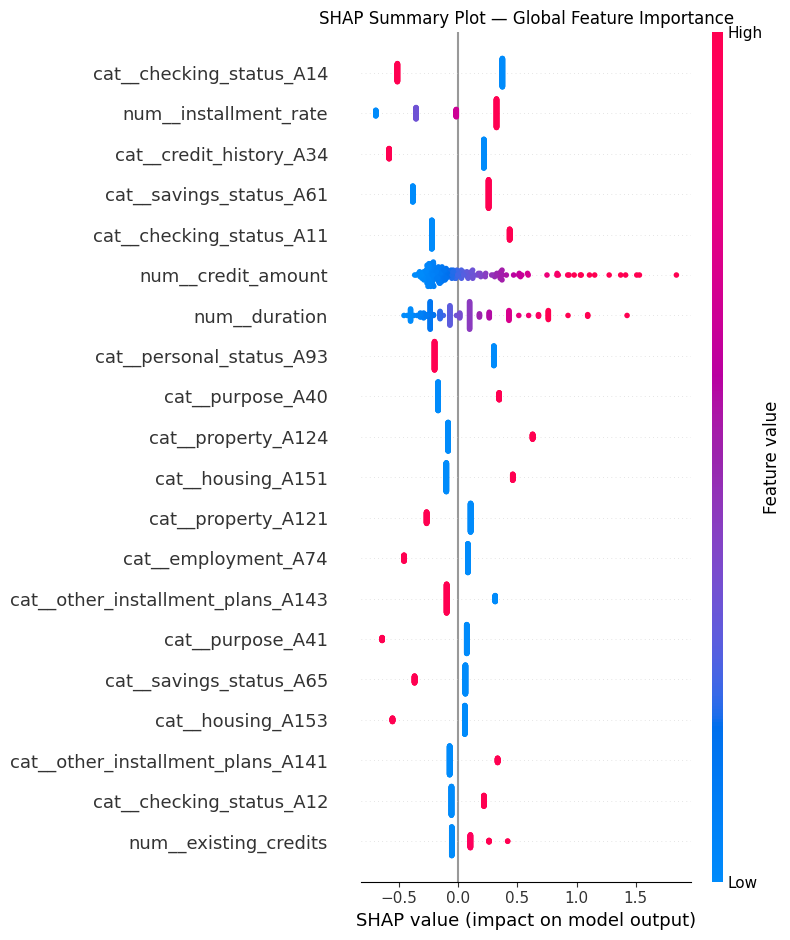

In [27]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values.values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot — Global Feature Importance")
plt.tight_layout()
plt.show()

### Step 14 — SHAP Feature Importance

The mean absolute SHAP value is used to quantify the overall importance of each processed feature across the test dataset. Higher values indicate that a feature has a greater average influence on the model predictions, regardless of the direction of its effect. This provides a numerical global feature-importance ranking alongside the SHAP summary visualization.


In [28]:
import numpy as np
import pandas as pd

# Calculate mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

print("Top 15 Features by Mean Absolute SHAP Value:")
shap_importance.head(15)

Top 15 Features by Mean Absolute SHAP Value:


,Feature,Mean_Absolute_SHAP
10,cat__checking_status_A14,0.427943
2,num__installment_rate,0.328632
15,cat__credit_history_A34,0.313747
26,cat__savings_status_A61,0.302180
7,cat__checking_status_A11,0.281553
1,num__credit_amount,0.276191
0,num__duration,0.274451
38,cat__personal_status_A93,0.241665
16,cat__purpose_A40,0.205431
46,cat__property_A124,0.167008


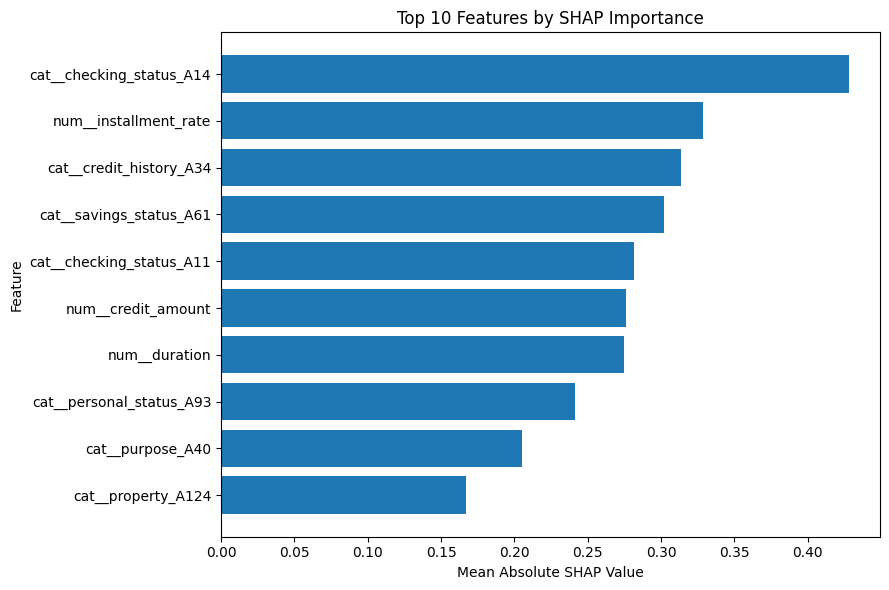

In [29]:
top_10_shap = shap_importance.head(10).sort_values(
    by="Mean_Absolute_SHAP"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_10_shap["Feature"],
    top_10_shap["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 Features by SHAP Importance")
plt.tight_layout()
plt.show()

**Observation:**
The SHAP feature-importance analysis identified `checking_status_A14` as the most influential processed feature, with a mean absolute SHAP value of 0.427943. Other highly influential features included `installment_rate` (0.328632), `credit_history_A34` (0.313747), `savings_status_A61` (0.302180), and `checking_status_A11` (0.281553). The results show which features have the strongest overall influence on model predictions, while the direction of their effects will be examined through further SHAP visualizations.


### Step 15 — SHAP Dependence Plot

A SHAP dependence plot is used to examine the relationship between a feature and its SHAP contribution. Unlike the global importance ranking, this visualization helps identify the direction and magnitude of a feature's effect on model predictions across individual observations.


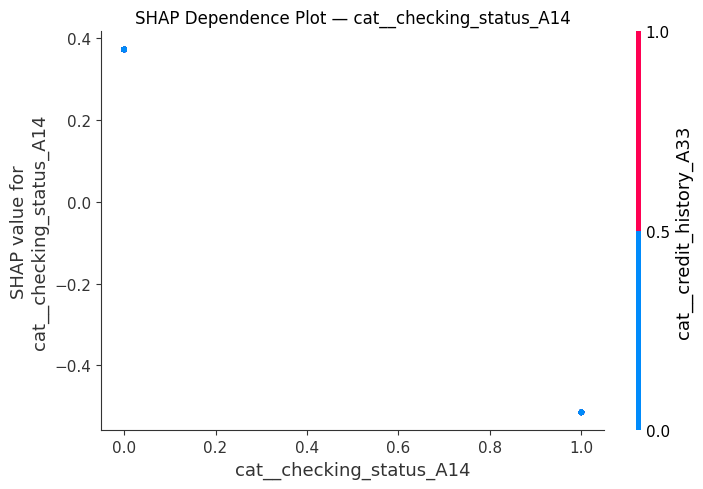

In [30]:
# Dependence plot for the most influential feature

top_feature = "cat__checking_status_A14"

shap.dependence_plot(
    top_feature,
    shap_values.values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title(f"SHAP Dependence Plot — {top_feature}")
plt.tight_layout()
plt.show()

**Observation:**
The SHAP dependence plot was successfully generated for `checking_status_A14`, the most influential processed feature identified in the global SHAP analysis. The plot provides a feature-level view of how changes in this encoded feature are associated with changes in the model's prediction contribution. It complements the global importance analysis by examining the feature's effect across individual test observations.


### Step 16 — SHAP Waterfall Plot

A SHAP waterfall plot provides a local explanation for an individual prediction. It shows how the most influential features move the model output from the baseline prediction toward the final prediction for a specific customer. This type of explanation is particularly useful for understanding individual credit decisions.


In [31]:
# Select one test customer for local explanation
sample_index = 0

print("Explaining test customer:", sample_index)
print("Actual class:", y_test.iloc[sample_index])
print("Predicted class:", y_pred[sample_index])
print("Predicted probability of Bad Credit:", round(y_prob[sample_index], 4))

Explaining test customer: 0
Actual class: 0
Predicted class: 0
Predicted probability of Bad Credit: 0.2268


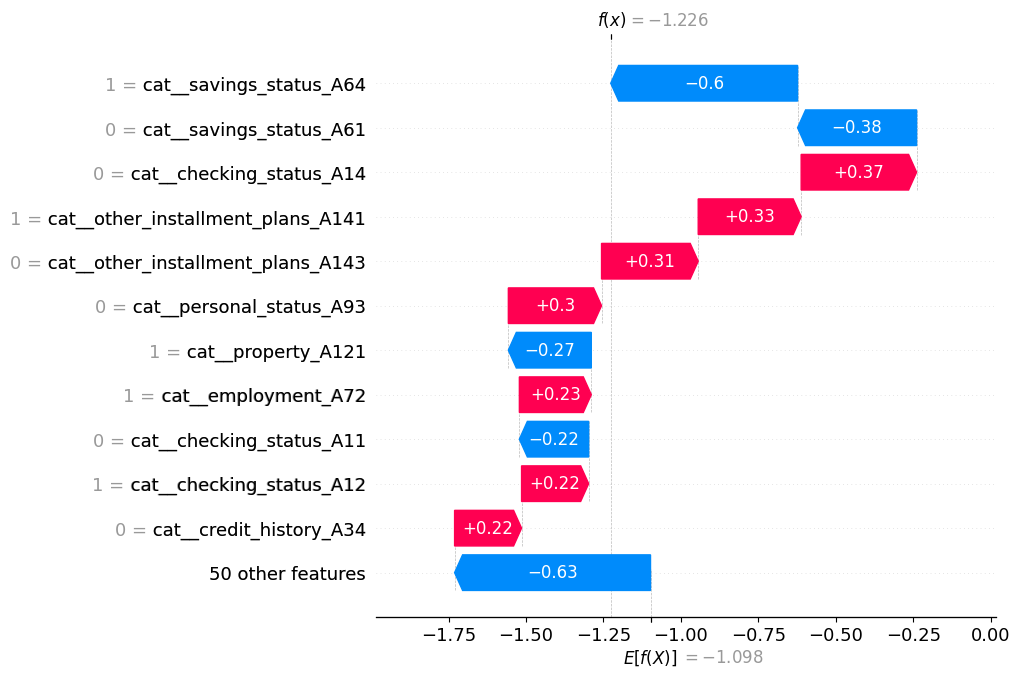

In [32]:
shap.plots.waterfall(
    shap_values[sample_index],
    max_display=12
)

In [33]:
# Display the feature contributions for the selected customer

local_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": shap_values.values[sample_index]
})

local_explanation["Absolute_SHAP"] = np.abs(
    local_explanation["SHAP_Value"]
)

local_explanation = local_explanation.sort_values(
    by="Absolute_SHAP",
    ascending=False
)

print("Top 10 Features Influencing This Customer's Prediction:")
local_explanation.head(10)

Top 10 Features Influencing This Customer's Prediction:


,Feature,SHAP_Value,Absolute_SHAP
29,cat__savings_status_A64,-0.603046,0.603046
26,cat__savings_status_A61,-0.384127,0.384127
10,cat__checking_status_A14,0.372587,0.372587
47,cat__other_installment_plans_A141,0.332254,0.332254
49,cat__other_installment_plans_A143,0.311996,0.311996
38,cat__personal_status_A93,0.300828,0.300828
43,cat__property_A121,-0.267751,0.267751
32,cat__employment_A72,0.232175,0.232175
7,cat__checking_status_A11,-0.223664,0.223664
8,cat__checking_status_A12,0.216547,0.216547


**Observation:**  
The SHAP waterfall analysis provided a local explanation for the selected customer's prediction. The customer was actually classified as Good Credit (0) and the model also predicted Good Credit, with a Bad Credit probability of 22.68%.

The strongest feature contributions were `cat__savings_status_A64` (-0.603046) and `cat__savings_status_A61` (-0.384127), which pushed the prediction toward Good Credit. In contrast, `cat__checking_status_A14` (0.372587), `cat__other_installment_plans_A141` (0.332254), and `cat__other_installment_plans_A143` (0.311996) pushed the prediction toward Bad Credit.

Overall, the waterfall explanation shows how different customer attributes contributed in opposite directions, resulting in the model's final Good Credit prediction.

### Step 17 — SHAP Force Plot

A SHAP force plot provides a local visual explanation of an individual prediction. It shows how different feature contributions push the model output toward Good Credit or Bad Credit. This visualization complements the SHAP waterfall plot by providing another view of the factors influencing the selected customer's prediction.

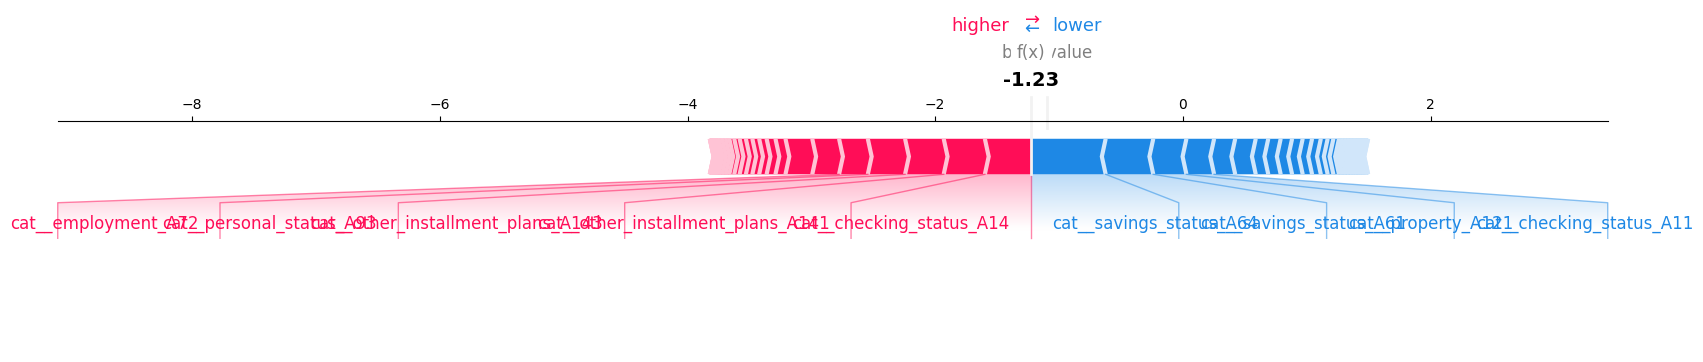

<Figure size 640x480 with 0 Axes>

In [34]:
# Generate SHAP force plot for the selected customer

shap.force_plot(
    shap_values.base_values[sample_index],
    shap_values.values[sample_index],
    feature_names=feature_names,
    matplotlib=True
)

plt.tight_layout()
plt.show()

**Observation:**  
The SHAP force plot provides a local explanation of the selected customer's prediction. The customer was actually classified as Good Credit (0), and the model also predicted Good Credit with a Bad Credit probability of 22.68%.

The strongest contributions toward Good Credit were `cat__savings_status_A64` (-0.603046), `cat__savings_status_A61` (-0.384127), and `cat__property_A121` (-0.267751). Features pushing the prediction toward Bad Credit included `cat__checking_status_A14` (0.372587), `cat__other_installment_plans_A141` (0.332254), and `cat__other_installment_plans_A143` (0.311996).

Overall, the explanation shows that the combined feature contributions resulted in a Good Credit prediction for this customer.

### Step 18 — SHAP KernelExplainer

KernelExplainer is a model-agnostic SHAP method that can explain predictions from different types of machine learning models. It estimates feature contributions by evaluating the model with different feature combinations. Since KernelExplainer can be computationally expensive, a small background sample and a limited number of test observations are used for efficient demonstration.

In [35]:
# Prepare dense numerical data for KernelExplainer

X_train_dense = (
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
)

X_test_dense = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

print("Dense training shape:", X_train_dense.shape)
print("Dense testing shape:", X_test_dense.shape)

Dense training shape: (800, 61)
Dense testing shape: (200, 61)


#### Step 18.2 — Create KernelExplainer

A small background sample is selected from the training data to reduce the computational cost of KernelExplainer. The Logistic Regression classifier's probability of Bad Credit is used as the prediction function so that SHAP can estimate how each feature contributes to the model output.

In [36]:
# Select a small background dataset for KernelExplainer
background_data = X_train_dense[:20]

# Define the model prediction function
def predict_proba_bad_credit(data):
    return classifier.predict_proba(data)[:, 1]

# Create KernelExplainer
kernel_explainer = shap.KernelExplainer(
    predict_proba_bad_credit,
    background_data
)

print("SHAP KernelExplainer created successfully.")
print("Background samples used:", len(background_data))

SHAP KernelExplainer created successfully.
Background samples used: 20


#### Step 18.3 — Calculate Kernel SHAP Values

Kernel SHAP values are calculated for a small subset of test observations. Limiting the number of observations keeps the computation efficient while demonstrating how the model-agnostic explainer estimates individual feature contributions.

In [37]:
# Select a small test sample for Kernel SHAP
X_kernel_sample = X_test_dense[:10]

# Calculate Kernel SHAP values
kernel_shap_values = kernel_explainer.shap_values(
    X_kernel_sample,
    nsamples=100
)

print("Kernel SHAP values calculated successfully.")
print("Explained samples:", len(X_kernel_sample))
print("SHAP values shape:", np.array(kernel_shap_values).shape)

  0%|          | 0/10 [00:00<?, ?it/s]

Kernel SHAP values calculated successfully.
Explained samples: 10
SHAP values shape: (10, 61)


**Observation:**  
Kernel SHAP successfully generated explanations for 10 test observations using the model-agnostic KernelExplainer. Each observation contains SHAP contributions for all 61 processed features. The limited sample size was used to keep the computational cost manageable while demonstrating model-agnostic feature attribution.

#### Step 18.4 — Kernel SHAP Summary Plot

A summary plot is generated from the Kernel SHAP values to visualize the overall feature contributions for the selected test observations. This provides a model-agnostic view of which processed features have the greatest influence on the predictions.

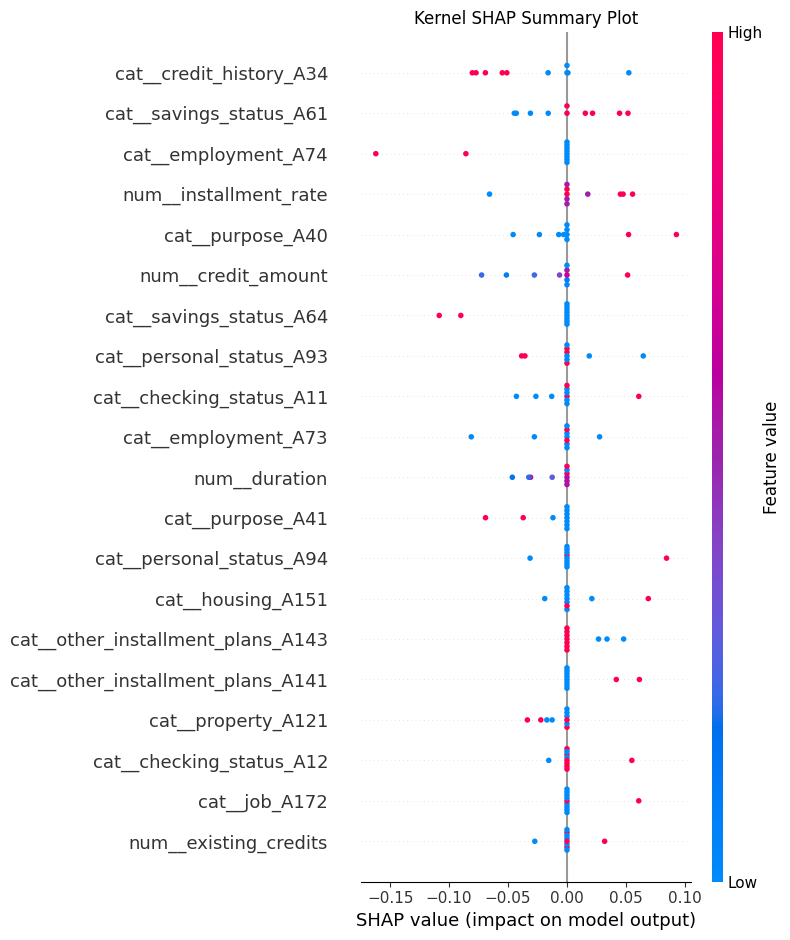

In [38]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    np.array(kernel_shap_values),
    X_kernel_sample,
    feature_names=feature_names,
    show=False
)

plt.title("Kernel SHAP Summary Plot")
plt.tight_layout()
plt.show()

#### Step 18.5 — Kernel SHAP Feature Importance

The mean absolute Kernel SHAP value is calculated to rank the processed features according to their overall influence on the selected test observations. Higher values indicate a greater average contribution to the model predictions.

In [39]:
# Calculate mean absolute Kernel SHAP importance

kernel_shap_array = np.array(kernel_shap_values)

kernel_mean_abs_shap = np.abs(
    kernel_shap_array
).mean(axis=0)

kernel_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": kernel_mean_abs_shap
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

print("Top 10 Features by Kernel SHAP Importance:")
kernel_importance.head(10)

Top 10 Features by Kernel SHAP Importance:


,Feature,Mean_Absolute_SHAP
15,cat__credit_history_A34,0.040184
26,cat__savings_status_A61,0.026817
34,cat__employment_A74,0.024793
2,num__installment_rate,0.023200
16,cat__purpose_A40,0.022391
1,num__credit_amount,0.020913
29,cat__savings_status_A64,0.019838
38,cat__personal_status_A93,0.015774
7,cat__checking_status_A11,0.014310
33,cat__employment_A73,0.013651


**Observation:**  
The Kernel SHAP analysis identified `cat__credit_history_A34` as the most influential feature among the selected test observations, with a mean absolute SHAP value of 0.040184. Other important features included `cat__savings_status_A61` (0.026817), `cat__employment_A74` (0.024793), `installment_rate` (0.023200), and `cat__purpose_A40` (0.022391). These results provide a model-agnostic ranking of the features with the greatest average influence on the selected predictions.

#### Step 18.6 — Compare SHAP Explainer Results

The Linear SHAP and Kernel SHAP approaches provide complementary interpretations of the same Logistic Regression model. LinearExplainer is efficient for linear models, while KernelExplainer is model-agnostic and can be applied to different model types. Their feature rankings are compared to identify common influential features.

In [40]:
# Compare the top 10 features from Linear SHAP and Kernel SHAP

linear_top10 = set(shap_importance.head(10)["Feature"])
kernel_top10 = set(kernel_importance.head(10)["Feature"])

common_features = linear_top10.intersection(kernel_top10)

print("Common features in both Top 10 rankings:")
for feature in common_features:
    print("-", feature)

print("\nNumber of common features:", len(common_features))

Common features in both Top 10 rankings:
- cat__purpose_A40
- cat__savings_status_A61
- num__credit_amount
- cat__personal_status_A93
- num__installment_rate
- cat__credit_history_A34
- cat__checking_status_A11

Number of common features: 7


**Observation:**  
The comparison showed that 7 features appeared in the Top 10 rankings of both Linear SHAP and Kernel SHAP. These common features were `credit_history_A34`, `savings_status_A61`, `installment_rate`, `credit_amount`, `personal_status_A93`, `checking_status_A11`, and `purpose_A40`. This agreement indicates that both explainers identified several consistent influential factors, while differences in ranking are expected because the two explainers use different explanation approaches.

### Step 19 — LIME Explainer Setup

LIME (Local Interpretable Model-agnostic Explanations) is used to provide a local explanation of an individual credit-risk prediction. It creates a simple interpretable approximation around a selected customer and identifies the features that contribute most to the model's prediction.

In [41]:
!pip install -q lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


#### Step 19.2 — Create LIME Tabular Explainer

The LIME Tabular Explainer is initialized using the preprocessed training data. The processed feature names and class names are provided so that the generated local explanations can identify the features and credit-risk classes clearly.

In [42]:
from lime.lime_tabular import LimeTabularExplainer

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_dense,
    feature_names=feature_names,
    class_names=["Good Credit", "Bad Credit"],
    mode="classification",
    random_state=42
)

print("LIME Tabular Explainer created successfully.")

LIME Tabular Explainer created successfully.


#### Step 19.3 — Generate LIME Explanation

LIME is applied to the selected test customer to identify the features that locally influence the model's prediction. The explanation focuses on the most influential features around this individual observation, providing a human-readable interpretation of the classification decision.

In [43]:
# Generate a LIME explanation for the selected customer

lime_explanation = lime_explainer.explain_instance(
    X_test_dense[sample_index],
    classifier.predict_proba,
    num_features=10
)

print("LIME explanation generated successfully.")
print("\nTop features influencing this customer's prediction:")

for feature, contribution in lime_explanation.as_list():
    print(f"{feature}: {contribution:.6f}")

LIME explanation generated successfully.

Top features influencing this customer's prediction:
cat__purpose_A46 <= 0.00: -0.164941
cat__checking_status_A14 <= 0.00: 0.142894
cat__checking_status_A11 <= 0.00: -0.122733
cat__credit_history_A34 <= 0.00: 0.120929
cat__property_A124 <= 0.00: -0.115221
cat__housing_A153 <= 0.00: 0.105736
cat__purpose_A41 <= 0.00: 0.104515
cat__credit_history_A30 <= 0.00: -0.101127
cat__savings_status_A61 <= 0.00: -0.098815
cat__housing_A151 <= 0.00: -0.098550


**Observation:**  
LIME generated a local explanation for the selected customer's prediction using 10 influential processed features. The strongest contribution toward Good Credit was `cat__purpose_A46 <= 0.00` with a weight of -0.164941, while `cat__checking_status_A14 <= 0.00` had the strongest contribution toward Bad Credit with a weight of 0.142894. Other influential features included `cat__checking_status_A11`, `cat__credit_history_A34`, and `cat__property_A124`.

The results demonstrate that LIME provides a local, human-readable approximation of the factors influencing an individual prediction.

#### Step 19.4 — LIME Explanation Visualization

A visualization of the LIME explanation is generated to display the most influential features and their local contributions for the selected customer. The visualization makes it easier to identify which features support or oppose the model's prediction.

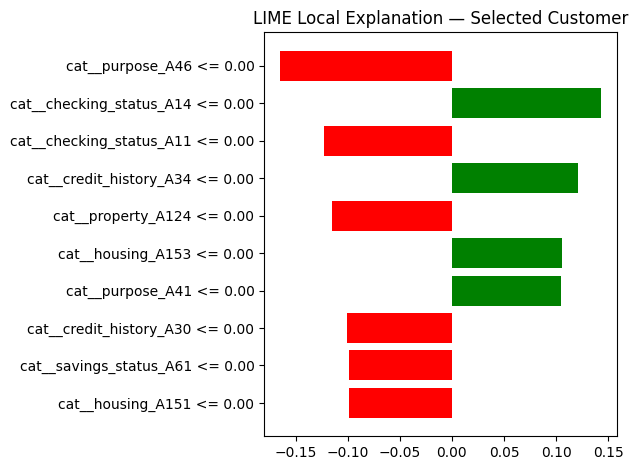

In [44]:
# Visualize the LIME explanation

fig = lime_explanation.as_pyplot_figure()

plt.title("LIME Local Explanation — Selected Customer")
plt.tight_layout()
plt.show()

### Step 20 — SHAP vs LIME Comparison

SHAP and LIME both provide local model explanations, but they use different approaches. SHAP assigns feature contributions based on Shapley values, while LIME builds a simple local approximation around an individual prediction. Their results are compared to identify features that are consistently influential across both interpretation methods.

In [45]:
# Extract top features from SHAP and LIME explanations

shap_top_features = set(
    local_explanation.head(10)["Feature"]
)

lime_top_features = set(
    [feature.split(" <= ")[0].split(" > ")[0]
     for feature, contribution in lime_explanation.as_list()]
)

common_lime_shap = shap_top_features.intersection(
    lime_top_features
)

print("Top 10 SHAP features:")
for feature in shap_top_features:
    print("-", feature)

print("\nTop 10 LIME features:")
for feature in lime_top_features:
    print("-", feature)

print("\nCommon features:")
for feature in common_lime_shap:
    print("-", feature)

print("\nNumber of common features:", len(common_lime_shap))

Top 10 SHAP features:
- cat__checking_status_A14
- cat__other_installment_plans_A141
- cat__savings_status_A61
- cat__personal_status_A93
- cat__savings_status_A64
- cat__other_installment_plans_A143
- cat__checking_status_A11
- cat__checking_status_A12
- cat__employment_A72
- cat__property_A121

Top 10 LIME features:
- cat__credit_history_A30
- cat__checking_status_A14
- cat__savings_status_A61
- cat__property_A124
- cat__housing_A151
- cat__checking_status_A11
- cat__credit_history_A34
- cat__purpose_A46
- cat__housing_A153
- cat__purpose_A41

Common features:
- cat__savings_status_A61
- cat__checking_status_A11
- cat__checking_status_A14

Number of common features: 3


**Observation:**  
The comparison showed that SHAP and LIME identified 3 common features among their Top 10 influential features for the selected customer: `cat__savings_status_A61`, `cat__checking_status_A11`, and `cat__checking_status_A14`. Although the remaining influential features differed between the two methods, the common features show that both approaches identified important aspects of the customer's financial profile. The differences are expected because SHAP and LIME use different approaches to explain the model locally.

### Step 21 — Fairness Audit Setup

A fairness audit is introduced to examine whether model predictions differ across customer groups. The `foreign_worker` attribute is used as an example audit dimension. Group-level prediction statistics will be calculated to provide a fairness-audit scaffold rather than a legal or definitive fairness assessment.

In [46]:
# Check the available groups in the selected fairness attribute

print("Foreign Worker Group Distribution:")
print(X_test["foreign_worker"].value_counts())

print("\nGroup Percentages:")
print(
    X_test["foreign_worker"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Foreign Worker Group Distribution:
foreign_worker
A201    194
A202      6
Name: count, dtype: int64

Group Percentages:
foreign_worker
A201    97.0
A202     3.0
Name: proportion, dtype: float64


**Observation:**  
The `foreign_worker` attribute was initially examined for the fairness audit. The test set contained 194 observations (97.0%) in group `A201` and only 6 observations (3.0%) in group `A202`. Because the second group is very small, comparing fairness metrics across these groups could produce unstable or misleading results. Therefore, a more suitable categorical attribute will be evaluated for the fairness-audit scaffold.

#### Step 21.2 — Evaluate Group Distribution

The `foreign_worker` attribute is not suitable for a reliable fairness comparison because one group contains only 3% of the test observations. A more balanced categorical attribute is therefore examined before performing the fairness audit.

In [47]:
# Check the distribution of personal status groups

print("Personal Status Group Distribution:")
print(X_test["personal_status"].value_counts())

print("\nGroup Percentages:")
print(
    X_test["personal_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Personal Status Group Distribution:
personal_status
A93    118
A92     61
A94     12
A91      9
Name: count, dtype: int64

Group Percentages:
personal_status
A93    59.0
A92    30.5
A94     6.0
A91     4.5
Name: proportion, dtype: float64


**Observation:**  
The `personal_status` attribute contains four groups: `A93` (59.0%), `A92` (30.5%), `A94` (6.0%), and `A91` (4.5%). Although the first two groups contain most of the observations, the smaller groups have limited representation. Therefore, `personal_status` is not considered ideal for a stable group-level fairness comparison, and another categorical attribute will be evaluated for the fairness-audit scaffold.

#### Step 21.3 — Evaluate Housing Groups

The `housing` attribute is examined as another possible grouping variable for the fairness audit. Its group distribution is checked to determine whether the available observations are sufficiently represented for a meaningful comparison.

In [48]:
print("Housing Group Distribution:")
print(X_test["housing"].value_counts())

print("\nGroup Percentages:")
print(
    X_test["housing"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Housing Group Distribution:
housing
A152    143
A151     35
A153     22
Name: count, dtype: int64

Group Percentages:
housing
A152    71.5
A151    17.5
A153    11.0
Name: proportion, dtype: float64


**Observation:**  
The `housing` attribute contains three groups: `A152` (71.5%), `A151` (17.5%), and `A153` (11.0%). Although `A152` is the dominant group, all three groups have more observations than the smallest groups found in the previously examined attributes. Therefore, `housing` is selected as the grouping attribute for the fairness-audit scaffold, while keeping the unequal group sizes in mind when interpreting the results.

#### Step 21.4 — Group-wise Fairness Metrics

Group-level performance metrics are calculated to examine whether the model behaves differently across the selected housing groups. Accuracy, precision, recall, F1-score, and positive prediction rate are reported for each group.

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

fairness_results = []

for group in sorted(X_test["housing"].unique()):
    mask = X_test["housing"] == group

    group_y_true = y_test[mask]
    group_y_pred = y_pred[mask]

    fairness_results.append({
        "Housing_Group": group,
        "Samples": len(group_y_true),
        "Accuracy": accuracy_score(group_y_true, group_y_pred),
        "Precision": precision_score(
            group_y_true,
            group_y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            group_y_true,
            group_y_pred,
            zero_division=0
        ),
        "F1_Score": f1_score(
            group_y_true,
            group_y_pred,
            zero_division=0
        ),
        "Positive_Prediction_Rate": group_y_pred.mean()
    })

fairness_df = pd.DataFrame(fairness_results)

print("Fairness Audit Results:")
fairness_df.round(4)

Fairness Audit Results:


,Housing_Group,Samples,Accuracy,Precision,Recall,F1_Score,Positive_Prediction_Rate
0,A151,35,0.7143,0.60,0.6923,0.6429,0.4286
1,A152,143,0.7972,0.68,0.4474,0.5397,0.1748
2,A153,22,0.7727,0.75,0.6667,0.7059,0.3636


**Observation:**  
The group-wise fairness audit showed differences in model performance across the three housing groups. Recall was highest for group `A151` at 69.23%, followed by `A153` at 66.67%, while `A152` had a lower recall of 44.74%. The positive prediction rate also varied across groups, ranging from 17.48% for `A152` to 42.86% for `A151`.

These differences indicate that model behavior is not identical across the housing groups. However, the groups have unequal sample sizes, particularly `A153` with only 22 observations, so these results should be treated as an audit scaffold rather than a definitive fairness conclusion.

#### Step 21.5 — Fairness Metric Disparity

The differences between the highest and lowest group-level metrics are calculated to summarize the observed variation across housing groups. This provides a simple quantitative fairness-audit indicator without making a definitive legal or ethical fairness claim.

In [50]:
# Calculate the range between highest and lowest group metrics

metrics_to_compare = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "Positive_Prediction_Rate"
]

fairness_disparity = {}

for metric in metrics_to_compare:
    fairness_disparity[metric] = (
        fairness_df[metric].max() -
        fairness_df[metric].min()
    )

disparity_df = pd.DataFrame(
    list(fairness_disparity.items()),
    columns=["Metric", "Max_Min_Difference"]
)

print("Fairness Metric Disparities:")
disparity_df.round(4)

Fairness Metric Disparities:


,Metric,Max_Min_Difference
0,Accuracy,0.0829
1,Precision,0.1500
2,Recall,0.2449
3,F1_Score,0.1662
4,Positive_Prediction_Rate,0.2537


**Observation:**  
The fairness audit evaluated the model's prediction behavior across customer groups using the `housing` attribute. Initially, `foreign_worker` and `personal_status` were examined, but they were not selected because some groups had very limited representation. The `housing` attribute provided a more suitable grouping for the audit, although its groups were still unequal in size.

Group-level evaluation showed differences in accuracy, precision, recall, F1-score, and positive prediction rate. The largest observed disparities were 0.2449 for recall and 0.2537 for positive prediction rate, indicating that the model does not behave identically across all housing groups.

These results provide a useful fairness-audit scaffold for identifying potential group-level differences. However, they should be interpreted cautiously because the dataset is relatively small, group sizes are unequal, and the analysis does not establish a definitive legal or ethical fairness conclusion.

### Step 22 — Random Forest Model for TreeExplainer

A Random Forest classifier is trained on the same preprocessed data to demonstrate tree-based SHAP interpretation. TreeExplainer is specifically designed for tree-based machine learning models and provides an efficient way to calculate feature contributions. The Logistic Regression model remains the primary baseline, while the Random Forest is introduced to demonstrate tree-based model interpretation.

In [51]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train on preprocessed training data
rf_classifier.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


#### Step 22.2 — Evaluate the Random Forest Model

The trained Random Forest model is evaluated on the unseen test data using accuracy, precision, recall, and F1-score. These metrics are compared with the Logistic Regression baseline to understand whether the tree-based model provides different predictive performance.

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Generate Random Forest predictions
rf_y_pred = rf_classifier.predict(X_test_processed)
rf_y_prob = rf_classifier.predict_proba(X_test_processed)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_y_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_y_pred, zero_division=0)

print("Random Forest Model Performance")
print("-------------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_y_pred))

Random Forest Model Performance
-------------------------------
Accuracy : 0.7600
Precision: 0.6765
Recall   : 0.3833
F1-Score : 0.4894

Confusion Matrix:
[[129  11]
 [ 37  23]]


**Observation:**  
The Random Forest model achieved an accuracy of 76.00%, with a precision of 67.65%, recall of 38.33%, and F1-score of 48.94%. The confusion matrix shows that 23 out of 60 bad-credit cases were correctly identified, while 37 were incorrectly classified as good credit.

Compared with the Logistic Regression baseline, the Random Forest achieved lower recall and F1-score on the test set. Therefore, it is not selected as the primary predictive model, but it provides a suitable tree-based model for demonstrating SHAP TreeExplainer.

#### Step 22.3 — Create SHAP TreeExplainer

TreeExplainer is applied to the trained Random Forest model because it is specifically designed for tree-based models. It efficiently calculates SHAP values for the individual trees and provides feature-level explanations for the model's predictions.

In [53]:
# Create TreeExplainer for the Random Forest model
tree_explainer = shap.TreeExplainer(rf_classifier)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


**Observation:**  
The SHAP TreeExplainer was successfully initialized for the trained Random Forest model. Since Random Forest is a tree-based classifier, TreeExplainer is an appropriate and efficient method for calculating SHAP feature contributions. The explainer is now ready to generate global and local explanations for the model's predictions.

#### Step 22.4 — Calculate Tree SHAP Values

The TreeExplainer is applied to the preprocessed test data to calculate feature contributions for the Random Forest predictions. These SHAP values will be used to analyze global feature importance and individual prediction behavior.

In [54]:
tree_shap_values = tree_explainer(X_test_processed)

print("Tree SHAP values calculated successfully.")
print("SHAP values shape:", tree_shap_values.values.shape)

Tree SHAP values calculated successfully.
SHAP values shape: (200, 61, 2)


**Observation:**  
Tree SHAP values were successfully calculated for all 200 test observations and 61 processed features. The resulting shape of `(200, 61, 2)` indicates that SHAP contributions were generated for both credit-risk classes: Good Credit (0) and Bad Credit (1). These values can now be used for global and local interpretation of the Random Forest model.

#### Step 22.5 — Tree SHAP Summary Plot

A SHAP summary plot is generated to provide a global interpretation of the Random Forest model. It ranks the processed features according to their overall contribution to the model predictions and helps identify the most influential factors in credit-risk classification.

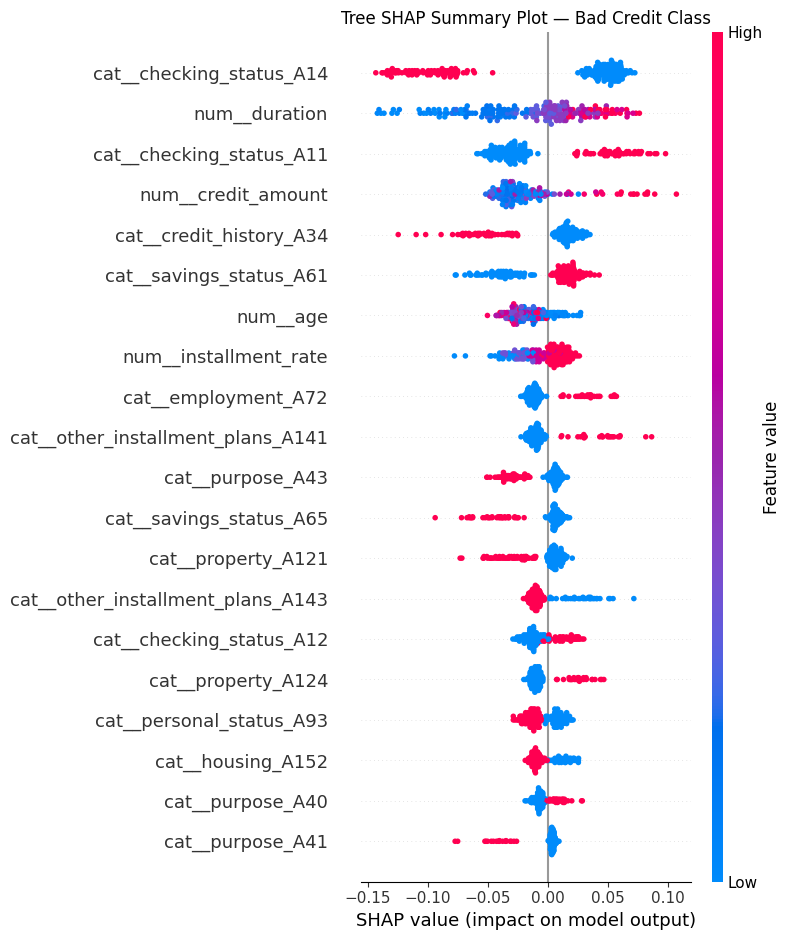

In [55]:
# Select SHAP values for Bad Credit class (class 1)
tree_shap_bad = tree_shap_values.values[:, :, 1]

plt.figure(figsize=(10, 7))

shap.summary_plot(
    tree_shap_bad,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title("Tree SHAP Summary Plot — Bad Credit Class")
plt.tight_layout()
plt.show()

In [56]:
# Calculate mean absolute Tree SHAP values
tree_mean_abs_shap = np.abs(tree_shap_bad).mean(axis=0)

tree_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": tree_mean_abs_shap
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

print("Top 10 Features by Tree SHAP Importance:")
tree_importance.head(10)

Top 10 Features by Tree SHAP Importance:


,Feature,Mean_Absolute_SHAP
10,cat__checking_status_A14,0.069321
0,num__duration,0.040706
7,cat__checking_status_A11,0.039407
1,num__credit_amount,0.029957
15,cat__credit_history_A34,0.027534
26,cat__savings_status_A61,0.024751
4,num__age,0.018886
2,num__installment_rate,0.015312
32,cat__employment_A72,0.014951
47,cat__other_installment_plans_A141,0.014655


**Observation:**  
The Tree SHAP analysis identified `cat__checking_status_A14` as the most influential feature for the Random Forest model, with a mean absolute SHAP value of 0.069321. Other important features included `duration` (0.040706), `checking_status_A11` (0.039407), `credit_amount` (0.029957), and `credit_history_A34` (0.027534).

These results provide a global view of the factors that most strongly influenced the Random Forest predictions. The SHAP importance values represent the magnitude of feature influence, while the direction of individual effects will be examined through local and dependence visualizations.

#### Step 22.6 — Tree SHAP Dependence Plot

A SHAP dependence plot is used to examine how the most influential feature affects the Random Forest predictions across individual observations. The plot shows the relationship between the feature value and its SHAP contribution, providing insight into the direction and magnitude of the feature's effect.

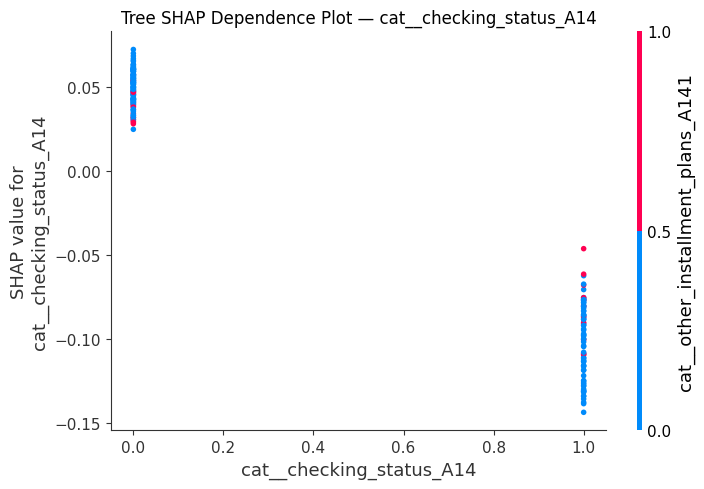

In [57]:
top_tree_feature = "cat__checking_status_A14"

shap.dependence_plot(
    top_tree_feature,
    tree_shap_bad,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title(f"Tree SHAP Dependence Plot — {top_tree_feature}")
plt.tight_layout()
plt.show()

**Observation:**  
The Tree SHAP dependence plot was successfully generated for `cat__checking_status_A14`, the most influential feature identified by the global Tree SHAP analysis. The visualization shows how the feature's values are associated with changes in its SHAP contribution across individual test observations. This provides additional insight into the feature's effect beyond its overall importance ranking.

#### Step 22.7 — Tree SHAP Waterfall Plot

A SHAP waterfall plot is used to provide a local explanation for an individual Random Forest prediction. It shows how the most influential features contribute toward the predicted credit-risk class, allowing the decision for a specific customer to be examined in detail.

In [58]:
# Display prediction details for the selected customer
print("Explaining test customer:", sample_index)
print("Actual class:", y_test.iloc[sample_index])
print("Random Forest predicted class:", rf_y_pred[sample_index])
print(
    "Random Forest probability of Bad Credit:",
    round(rf_y_prob[sample_index], 4)
)

Explaining test customer: 0
Actual class: 0
Random Forest predicted class: 0
Random Forest probability of Bad Credit: 0.33


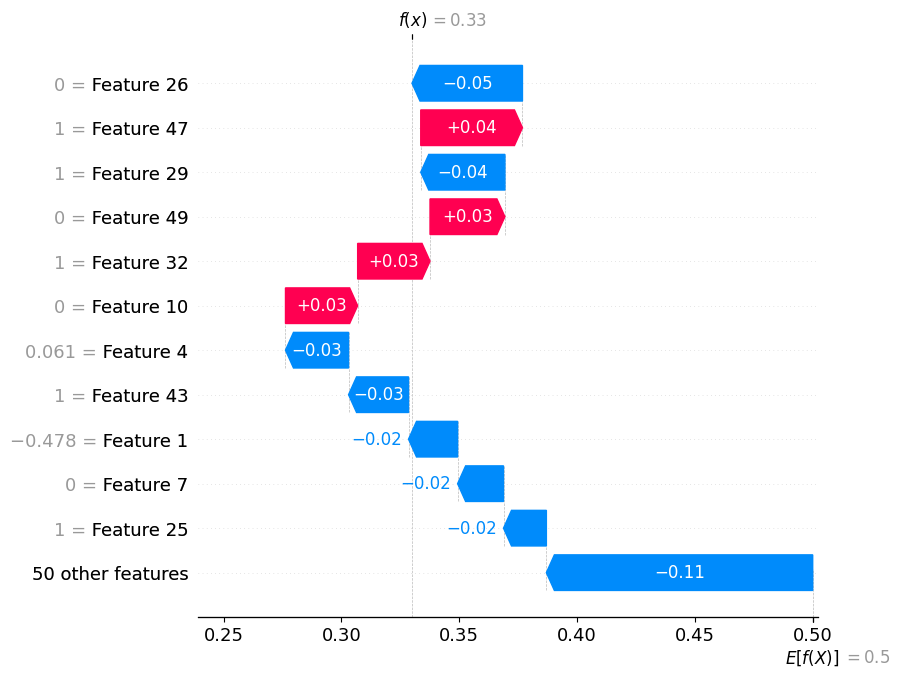

In [59]:
# Tree SHAP local explanation for the selected customer
shap.plots.waterfall(
    tree_shap_values[sample_index, :, 1],
    max_display=12
)

In [60]:
# Exact numerical values shown in the Tree SHAP waterfall plot

local_tree_shap = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": tree_shap_bad[sample_index]
})

local_tree_shap["Direction"] = np.where(
    local_tree_shap["SHAP_Value"] > 0,
    "Toward Bad Credit",
    "Toward Good Credit"
)

local_tree_shap["Absolute_SHAP"] = np.abs(
    local_tree_shap["SHAP_Value"]
)

local_tree_shap = local_tree_shap.sort_values(
    "Absolute_SHAP",
    ascending=False
)

print("Tree SHAP Waterfall — Exact Feature Contributions")
print("--------------------------------------------------")
print(local_tree_shap[
    ["Feature", "SHAP_Value", "Direction"]
].head(12).to_string(index=False))

print("\nPrediction Summary")
print("------------------")
print("Actual Class:", y_test.iloc[sample_index])
print("Predicted Class:", rf_y_pred[sample_index])
print("Bad Credit Probability:", round(rf_y_prob[sample_index], 4))

Tree SHAP Waterfall — Exact Feature Contributions
--------------------------------------------------
                          Feature  SHAP_Value          Direction
          cat__savings_status_A61   -0.046878 Toward Good Credit
cat__other_installment_plans_A141    0.043164  Toward Bad Credit
          cat__savings_status_A64   -0.035723 Toward Good Credit
cat__other_installment_plans_A143    0.031787  Toward Bad Credit
              cat__employment_A72    0.030712  Toward Bad Credit
         cat__checking_status_A14    0.030629  Toward Bad Credit
                         num__age   -0.026766 Toward Good Credit
               cat__property_A121   -0.025450 Toward Good Credit
               num__credit_amount   -0.020836 Toward Good Credit
         cat__checking_status_A11   -0.019476 Toward Good Credit
                 cat__purpose_A49   -0.018197 Toward Good Credit
                cat__housing_A152   -0.014411 Toward Good Credit

Prediction Summary
------------------
Actual Class: 0

**Observation:**  
The Tree SHAP waterfall explanation was generated for the selected customer. The customer was actually classified as Good Credit (0), and the Random Forest also predicted Good Credit (0), with a Bad Credit probability of 33.00%.

The strongest contribution toward Good Credit came from `cat__savings_status_A61` (-0.046878), followed by `cat__savings_status_A64` (-0.035723), `age` (-0.026766), and `property_A121` (-0.025450). In contrast, `cat__other_installment_plans_A141` (0.043164) and `cat__other_installment_plans_A143` (0.031787) were the strongest contributors toward Bad Credit, followed by `employment_A72` (0.030712) and `checking_status_A14` (0.030629).

Overall, the combination of positive and negative feature contributions resulted in the model's final Good Credit prediction.

### Step 23 — Global vs Local Interpretability

Global interpretability explains which features are generally influential across multiple predictions, while local interpretability explains why a particular prediction was made for an individual customer. SHAP supports both perspectives, allowing overall feature importance to be compared with the feature contributions for a specific credit decision.

In [61]:
# Global SHAP importance
global_top5 = shap_importance.head(5)[
    ["Feature", "Mean_Absolute_SHAP"]
]

# Local SHAP importance for the selected customer
local_top5 = local_explanation.head(5)[
    ["Feature", "SHAP_Value"]
]

print("Top 5 Global SHAP Features:")
print(global_top5.to_string(index=False))

print("\nTop 5 Local SHAP Features:")
print(local_top5.to_string(index=False))

Top 5 Global SHAP Features:
                 Feature  Mean_Absolute_SHAP
cat__checking_status_A14            0.427943
   num__installment_rate            0.328632
 cat__credit_history_A34            0.313747
 cat__savings_status_A61            0.302180
cat__checking_status_A11            0.281553

Top 5 Local SHAP Features:
                          Feature  SHAP_Value
          cat__savings_status_A64   -0.603046
          cat__savings_status_A61   -0.384127
         cat__checking_status_A14    0.372587
cat__other_installment_plans_A141    0.332254
cat__other_installment_plans_A143    0.311996


**Observation:**  
The global SHAP analysis identified `checking_status_A14`, `installment_rate`, `credit_history_A34`, `savings_status_A61`, and `checking_status_A11` as the five most influential features across the test dataset. In contrast, the local explanation for the selected customer was mainly influenced by `savings_status_A64`, `savings_status_A61`, `checking_status_A14`, and the two `other_installment_plans` features.

This comparison shows that globally important features are not always the same as the features that have the strongest influence on an individual prediction. Therefore, both global and local interpretability are important when explaining credit-risk models.

### Step 24 — Feature Importance vs Feature Effects

Feature importance measures how strongly a feature influences the model overall, while feature effects show the direction of that influence for individual predictions. A feature can have high importance but may push different observations toward Good Credit or Bad Credit depending on the customer's characteristics.

The SHAP values are therefore examined using both their absolute magnitude and their sign. Mean absolute SHAP values are used to measure overall importance, while positive and negative SHAP values indicate the direction of the feature's contribution.

In [62]:
# Select the top 10 globally important SHAP features
top_features = shap_importance.head(10)["Feature"].tolist()

# Calculate average SHAP effect for each top feature
effect_analysis = pd.DataFrame({
    "Feature": top_features,
    "Mean_Absolute_SHAP": [
        shap_importance.loc[
            shap_importance["Feature"] == feature,
            "Mean_Absolute_SHAP"
        ].values[0]
        for feature in top_features
    ],
    "Mean_SHAP_Effect": [
        shap_values.values[:, feature_names.tolist().index(feature)].mean()
        for feature in top_features
    ]
})

# Determine overall direction
effect_analysis["Overall_Direction"] = np.where(
    effect_analysis["Mean_SHAP_Effect"] > 0,
    "Toward Bad Credit",
    "Toward Good Credit"
)

print("Feature Importance vs Feature Effects:")
print(effect_analysis.round(4).to_string(index=False))

Feature Importance vs Feature Effects:
                 Feature  Mean_Absolute_SHAP  Mean_SHAP_Effect  Overall_Direction
cat__checking_status_A14              0.4279            0.0266  Toward Bad Credit
   num__installment_rate              0.3286            0.0170  Toward Bad Credit
 cat__credit_history_A34              0.3137            0.0040  Toward Bad Credit
 cat__savings_status_A61              0.3022            0.0256  Toward Bad Credit
cat__checking_status_A11              0.2816           -0.0428 Toward Good Credit
      num__credit_amount              0.2762            0.0391  Toward Bad Credit
           num__duration              0.2745            0.0245  Toward Bad Credit
cat__personal_status_A93              0.2417            0.0050  Toward Bad Credit
        cat__purpose_A40              0.2054           -0.0671 Toward Good Credit
      cat__property_A124              0.1670            0.0214  Toward Bad Credit


**Observation:**  
The analysis shows that feature importance and feature effects provide different types of information. `checking_status_A14` had the highest overall importance with a mean absolute SHAP value of 0.4279, while its average SHAP effect was positive (0.0266), indicating an overall tendency toward Bad Credit.

Similarly, `credit_amount` had a relatively high importance of 0.2762 and a positive mean SHAP effect of 0.0391. In contrast, `checking_status_A11` had a high importance of 0.2816 but a negative mean SHAP effect of -0.0428, indicating an overall tendency toward Good Credit. `purpose_A40` also showed a negative average effect of -0.0671.

This demonstrates that mean absolute SHAP values describe the magnitude of feature importance, while the sign of SHAP values provides information about the direction of the feature's effect.

#### Step 24.2 — Visualize Feature Importance and Effect Direction

The top globally important features are visualized using their mean absolute SHAP values and mean SHAP effects. The importance values show the magnitude of influence, while the effect direction indicates whether the average contribution moves predictions toward Good Credit or Bad Credit.

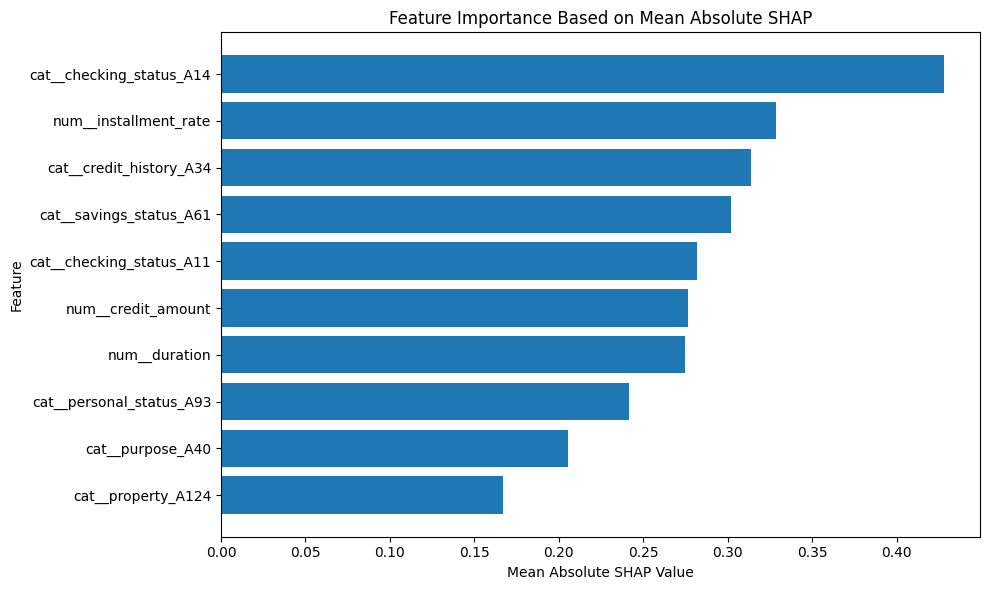

In [63]:
plt.figure(figsize=(10, 6))

plt.barh(
    effect_analysis["Feature"],
    effect_analysis["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Feature Importance Based on Mean Absolute SHAP")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

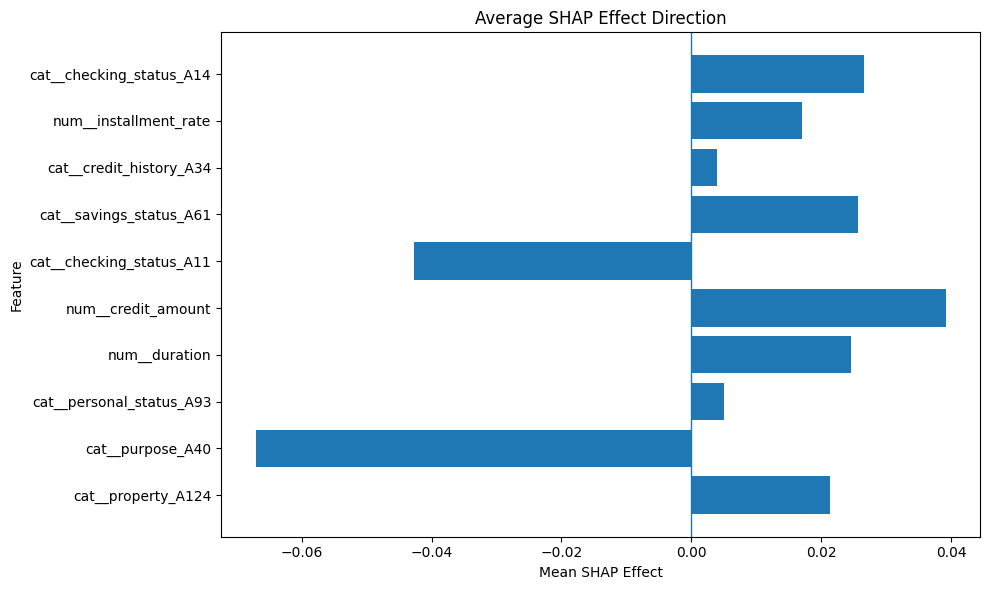

In [64]:
plt.figure(figsize=(10, 6))

plt.barh(
    effect_analysis["Feature"],
    effect_analysis["Mean_SHAP_Effect"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Mean SHAP Effect")
plt.ylabel("Feature")
plt.title("Average SHAP Effect Direction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Step 25 — Reproducibility and Best Practices

Reproducibility is important for reliable machine learning interpretation because the same preprocessing, model settings, and random seeds should produce consistent results. The workflow uses fixed random states, a preprocessing pipeline, and clearly separated training and testing data.

The interpretation process also follows best practices by avoiding data leakage, using the appropriate SHAP explainer for each model type, keeping Kernel SHAP computationally limited, and distinguishing global feature importance from local feature effects. SHAP and LIME explanations are treated as model interpretations rather than causal explanations.

In [65]:
print("Reproducibility Settings")
print("------------------------")
print("Train-test split random_state:", 42)
print("Logistic Regression random_state:", 42)
print("Random Forest random_state:", 42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Processed features:", len(feature_names))

Reproducibility Settings
------------------------
Train-test split random_state: 42
Logistic Regression random_state: 42
Random Forest random_state: 42
Training samples: 800
Testing samples: 200
Processed features: 61


#### Step 25.2 — Interpretation Best Practices

The following practices were followed throughout the model interpretation workflow:

- Data was split into training and testing sets before model fitting.
- Preprocessing was fitted only on the training data to reduce leakage risk.
- Numerical and categorical features were processed using a structured pipeline.
- Logistic Regression was interpreted using SHAP LinearExplainer.
- Random Forest was interpreted using SHAP TreeExplainer.
- KernelExplainer was demonstrated using a limited background and test sample because of its higher computational cost.
- LIME was used for local interpretation of an individual prediction.
- Global and local explanations were analyzed separately.
- SHAP importance values were distinguished from the direction of feature effects.
- Fairness results were treated as an audit scaffold rather than a definitive fairness conclusion.
- Fixed random states were used where applicable to improve reproducibility.
- SHAP and LIME explanations were not interpreted as evidence of causal relationships.

### Step 26 — Final Model Comparison

The Logistic Regression baseline and Random Forest model are compared using the same test dataset and evaluation metrics. The comparison helps determine the predictive performance of both models while also showing why different SHAP explainers were used.

Logistic Regression serves as the primary baseline because it achieved stronger recall and F1-score on the test set. Random Forest is included as a tree-based model to demonstrate SHAP TreeExplainer, even though its predictive performance was lower on this dataset.

In [66]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1-Score": [
        f1,
        rf_f1
    ]
})

print("Model Performance Comparison:")
print(model_comparison.round(4).to_string(index=False))

Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression      0.78     0.6667  0.5333    0.5926
      Random Forest      0.76     0.6765  0.3833    0.4894


#### Step 26.2 — Model Performance Visualization

A bar chart is used to compare the main evaluation metrics of the Logistic Regression and Random Forest models. This provides a clear visual summary of their predictive performance on the unseen test data.

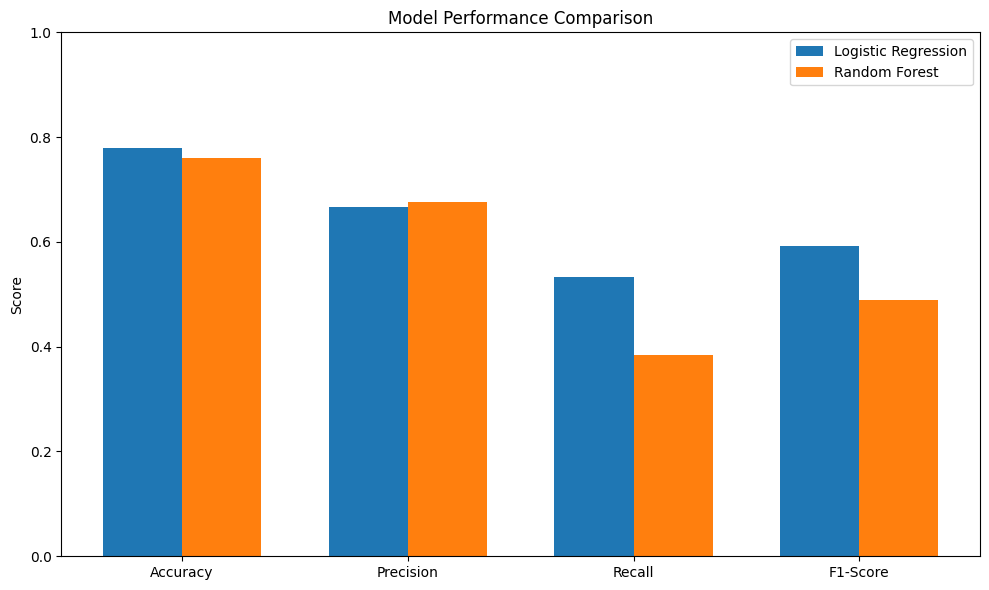

In [67]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    model_comparison.iloc[0][metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width / 2,
    model_comparison.iloc[1][metrics],
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:**  
The Logistic Regression model performed better overall than the Random Forest model on the test dataset. Logistic Regression achieved 78.00% accuracy, 66.67% precision, 53.33% recall, and an F1-score of 59.26%. Random Forest achieved 76.00% accuracy, 67.65% precision, 38.33% recall, and an F1-score of 48.94%.

Although Random Forest achieved slightly higher precision, Logistic Regression provided better recall and F1-score. Therefore, Logistic Regression is retained as the primary baseline model, while Random Forest was used mainly to demonstrate tree-based SHAP interpretation with TreeExplainer.

### Step 27 — Final Results and Limitations

The interpretation workflow successfully demonstrated multiple model explanation techniques for credit-risk classification. Logistic Regression was used as the primary baseline model, while Random Forest was used to demonstrate tree-based SHAP interpretation.

The Logistic Regression model achieved 78.00% accuracy, 66.67% precision, 53.33% recall, and 59.26% F1-score on the test set. SHAP provided global and local explanations through LinearExplainer, KernelExplainer, summary plots, dependence plots, waterfall plots, and force plots. LIME provided an additional local explanation for an individual customer.

A fairness-audit scaffold was also implemented using the `housing` attribute, showing differences in model performance and positive prediction rates across groups.

#### Limitations

- The dataset contains only 1,000 records, which limits the generalizability of the findings.
- Some fairness groups have relatively small sample sizes, making group-level comparisons less stable.
- Kernel SHAP was demonstrated on a limited sample because it is computationally expensive.
- One-hot encoding produces multiple processed features for a single categorical attribute, which can make explanations more detailed but less intuitive.
- SHAP and LIME describe model behavior and should not be interpreted as causal explanations.
- The fairness analysis is an audit scaffold and does not establish a definitive legal or ethical fairness conclusion.

### Step 28 — Conclusion

This task demonstrated how machine learning predictions can be interpreted using SHAP and LIME in a credit-risk classification scenario. The workflow covered data preprocessing, leakage-safe model training, baseline evaluation, global and local interpretability, model-agnostic and model-specific SHAP explainers, LIME explanations, and a fairness-audit scaffold.

Logistic Regression was retained as the primary model because it achieved better recall and F1-score than the Random Forest model on the test data. SHAP and LIME provided complementary explanations that helped identify the features influencing individual and overall predictions.

Overall, the task demonstrates that model interpretation can improve transparency and support more understandable credit-risk decisions, while also highlighting the importance of considering model limitations, fairness, and reproducibility.